# Data Analysis
### Purpose: Analyze dataset characteristics, class distributions, and image properties

## Notebook guidance
- Deep-dive analysis: aggregates stats and visuals across the dataset.
- Confirm data/annotation paths; run on subsets first if the dataset is large.
- Outputs plots/tables—ensure output directories exist and are writable.
- Validate class mapping consistency with training notebooks.


#### Imports and setup

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]

from collections import defaultdict

import torch

import cv2
import numpy as np
from torch.utils.data import DataLoader
from src.exploration.content import crop_bbox, crop_bbox_with_context, crop_mask_with_context, crop_mask, pad_to_size, \
    expand_crop_with_background
from src.exploration.class_explorer import explore_bboxes
from src.data.annotations import load_json_annotations
from src.data.augmentations import get_train_augmentations, get_val_augmentations
from src.data.loaders import ImageMaskDataset
from src.exploration.filters import cv2_apply_gaussian, cv2_apply_laplacian, cv2_apply_sobel
from src.exploration.kernels import apply_kernel_using_convolution, get_kernels
from src.exploration.visualize import show_side_by_side
from src.prediction.pipeline import Predictor
from src.training.engine import run_training
from src.utils.config import Config
from src.utils.helpers import init_notebook, p, t, c
from src.utils.versioning import VersionManager
from src.prediction.validation import analyze_validation_metrics


In [2]:
config = Config.load(root = root)
init_notebook(config.train.seed)

entries = load_json_annotations(config.paths.annotations)
image_dir = config.paths.train_images


=== init_notebook ===
Done


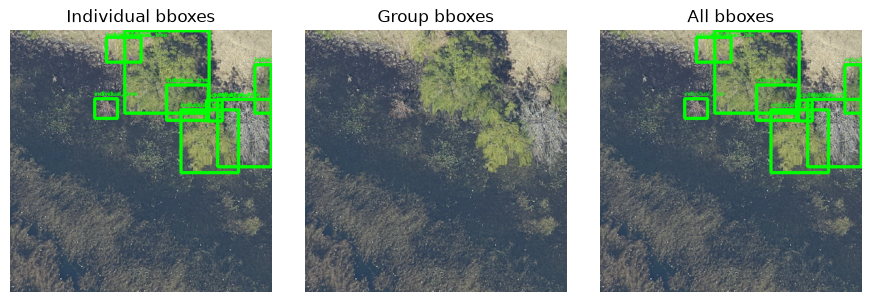

Entry index: 13


In [3]:
# Pick a mid sample when the set is large; fall back for the small public sample
idx = min(42, len(entries) - 1)
explore_bboxes(config, entries[idx])
p("Entry index", idx)


#### Step 1: Identify single class and group images

In [4]:
# Class distribution

individual_entries = [e for e in entries if any(item.cls == "individual_tree" for item in e.items)]
group_entries = [e for e in entries if any(item.cls == "group_of_trees" for item in e.items)]
both_entries = [e for e in entries if
                any(item.cls == "individual_tree" for item in e.items) and
                any(item.cls == "group_of_trees" for item in e.items)]

p("Total images", len(entries))
p("Images with individual trees", len(individual_entries))
p("Images with tree groups", len(group_entries))
p("Images with both classes", len(both_entries))


Total images: 14
Images with individual trees: 14
Images with tree groups: 0
Images with both classes: 0


=== Sample Visualizations ===
Individual tree example:


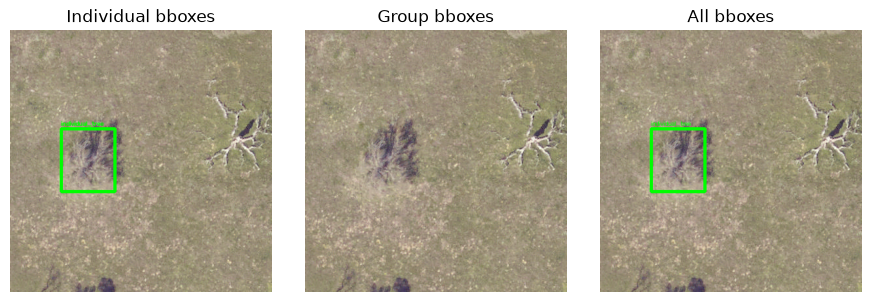

In [5]:
t("Sample Visualizations")

# Show examples of each class type
sample_individual = individual_entries[0] if individual_entries else None
sample_group = group_entries[0] if group_entries else None
sample_both = both_entries[0] if both_entries else None

if sample_individual:
    p("Individual tree example:")
    explore_bboxes(config, sample_individual)

if sample_group:
    p("Tree group example:")
    explore_bboxes(config, sample_group)


In [6]:
t("Dataset Report")
# dataset_report(config, entries)


=== Dataset Report ===


Quick demo of context-aware cropping on 3 samples:


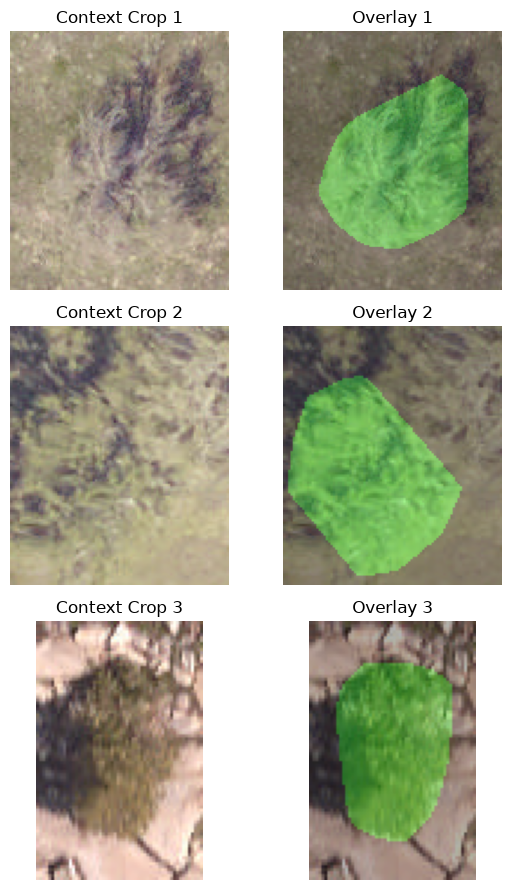

In [7]:
# sample
if len(individual_entries) > 0:
    p("Quick demo of context-aware cropping on 3 samples:")

    demo_images = []
    demo_titles = []

    for i in range(min(3, len(individual_entries))):
        entry = individual_entries[i]
        if entry.items:
            item = entry.items[0]  # First item only

            try:
                # Show the concept
                crop, context_bbox = crop_bbox_with_context(image_dir, entry, item, context_factor = 1.5)
                mask_crop = crop_mask_with_context(entry, item, context_bbox)

                # Quick resize for display
                if crop.shape[0] > 200 or crop.shape[1] > 200:
                    crop = cv2.resize(crop, (200, 200))
                    mask_crop = cv2.resize(mask_crop, (200, 200), interpolation = cv2.INTER_NEAREST)

                # Create overlay
                mask_rgb = np.zeros_like(crop)
                mask_rgb[:, :, 1] = mask_crop * 255
                overlay = cv2.addWeighted(crop, 0.7, mask_rgb, 0.3, 0)

                demo_images.extend([crop, overlay])
                demo_titles.extend([f"Context Crop {i + 1}", f"Overlay {i + 1}"])

            except Exception as e:
                p(f"Demo failed for sample {i + 1}: {e}", color1 = "orange")

    if demo_images:
        show_side_by_side(
                *demo_images,
                titles = tuple(demo_titles),
                maxcolumns = 2
        )


#### Step 2: Extract each bbox from each single image and inspect

In [8]:
sample_entry = individual_entries[0]


##### Collect all crops first and record their shapes

Individual crop count: 5
Max dimensions needed: 140x105


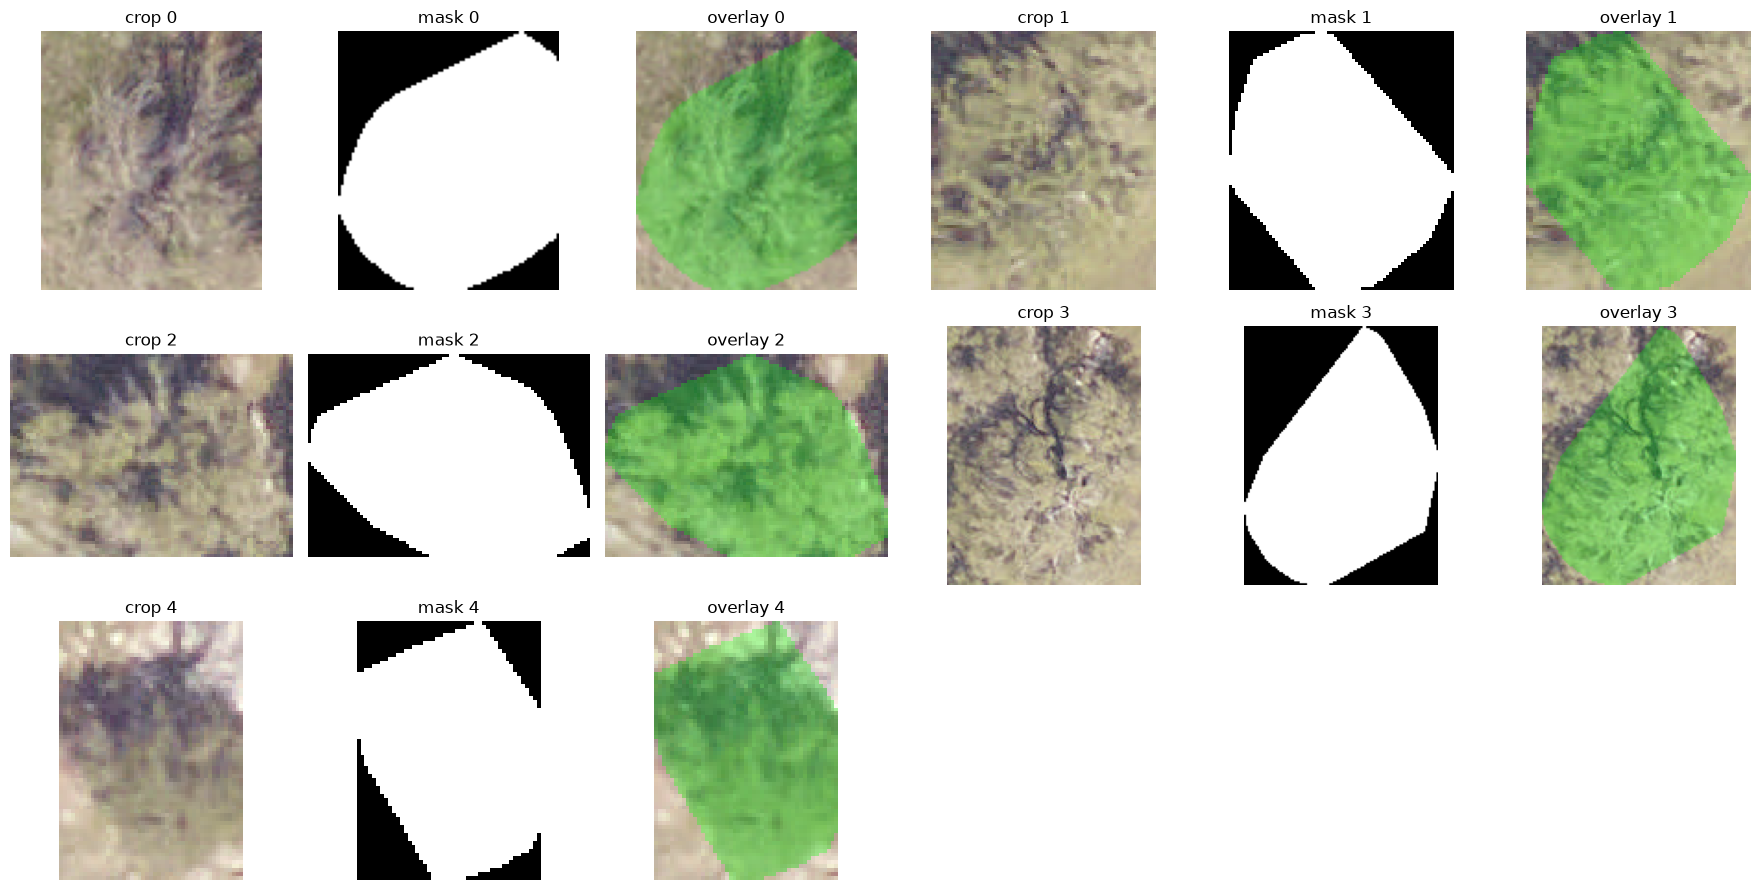

In [9]:
# Extract some individual bbox crops for inspection
individual_crops = []
individual_masks = []

individual_crops_count = 5
for e_idx, entry in enumerate(individual_entries[:5]):
    for j_idx, item in enumerate(entry.items):
        if item.cls == "individual_tree":
            crop = crop_bbox(image_dir, entry, item)
            mask_crop = crop_mask(entry, item)
            individual_crops.append(crop)
            individual_masks.append(mask_crop)

            if len(individual_crops) >= individual_crops_count:
                break
    if len(individual_crops) >= individual_crops_count:
        break

# Calculate dimensions
all_heights = [crop.shape[0] for crop in individual_crops]
all_widths = [crop.shape[1] for crop in individual_crops]
max_h = max(all_heights)
max_w = max(all_widths)

p("Individual crop count", len(individual_crops))
p("Max dimensions needed", f"{max_h}x{max_w}")

# Show first few crops
if individual_crops:
    triplets = []
    titles = []

    for i in range(min(individual_crops_count, len(individual_crops))):
        crop = individual_crops[i]
        mask_crop = individual_masks[i]

        # Create overlay
        overlay = crop.copy()
        overlay[mask_crop > 0] = [0, 255, 0]  # Green for trees
        overlay = cv2.addWeighted(crop, 0.7, overlay, 0.3, 0)

        triplets.extend([crop, mask_crop * 255, overlay])
        titles.extend([f"crop {i}", f"mask {i}", f"overlay {i}"])

    show_side_by_side(*triplets, titles = tuple(titles), maxcolumns = 6)


#### Step 3: Apply filters and kernel exploration on crops

##### Direct crop

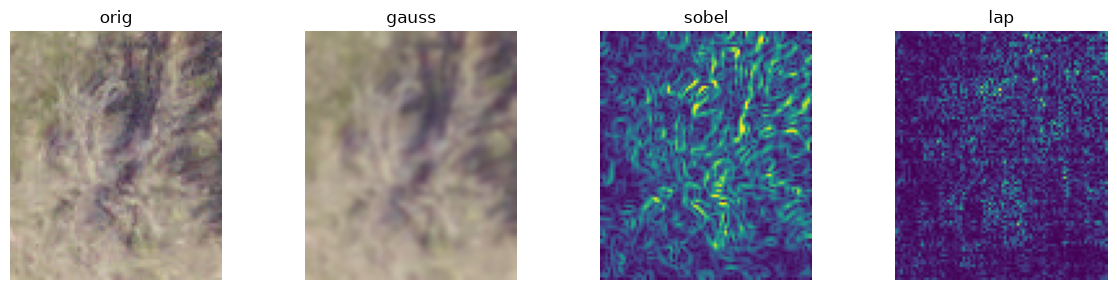

In [10]:
crop = crop_bbox(image_dir, sample_entry, sample_entry.items[0])
gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

ga = cv2_apply_gaussian(crop)
so = cv2_apply_sobel(crop)
la = cv2_apply_laplacian(crop)

show_side_by_side(crop, ga, so, la, titles = ("orig", "gauss", "sobel", "lap"))


##### Padded Crop

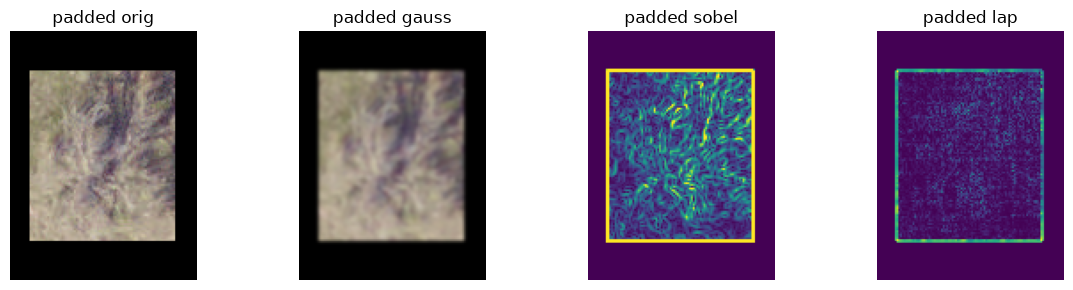

In [11]:
padded = pad_to_size(crop, max_h, max_w)

ga_p = cv2_apply_gaussian(padded)
so_p = cv2_apply_sobel(padded)
la_p = cv2_apply_laplacian(padded)

show_side_by_side(
        padded,
        ga_p,
        so_p,
        la_p,
        titles = ("padded orig", "padded gauss", "padded sobel", "padded lap"),
        maxcolumns = 4
)


##### Background Expanded Crop

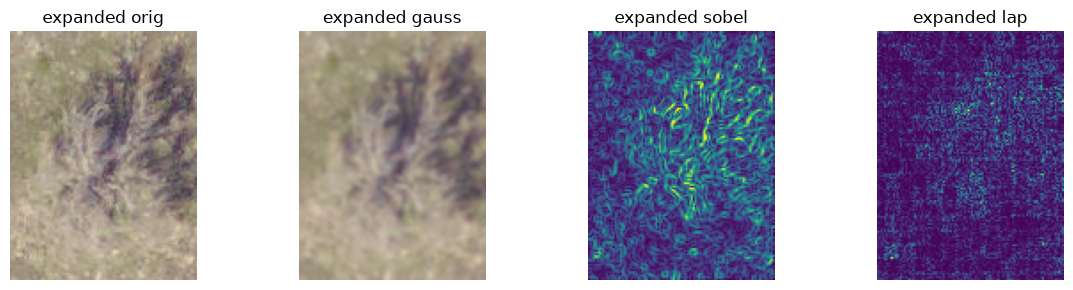

In [12]:
# Create full image mask for background expansion
full_mask = np.zeros((sample_entry.height, sample_entry.width), dtype = np.uint8)
sample_seg = sample_entry.items[0].segmentation
if sample_seg and len(sample_seg) >= 4:
    poly = np.array(sample_seg, dtype = np.int32).reshape(-1, 2)
    cv2.fillPoly(full_mask, [poly], 1)

# Load full image
img_path = image_dir / sample_entry.image_path.name
full_img = cv2.imread(str(img_path))
full_img = cv2.cvtColor(full_img, cv2.COLOR_BGR2RGB)

# Expand with background
expanded, expanded_mask = expand_crop_with_background(

        full_img, full_mask, sample_entry.items[0].bbox, max_h, max_w
)

ga_p = cv2_apply_gaussian(expanded)
so_p = cv2_apply_sobel(expanded)
la_p = cv2_apply_laplacian(expanded)

show_side_by_side(
        expanded,
        ga_p,
        so_p,
        la_p,
        titles = ("expanded orig", "expanded gauss", "expanded sobel", "expanded lap"),
        maxcolumns = 4
)


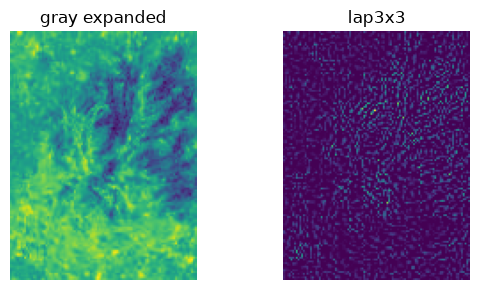

In [13]:
kernels = get_kernels()
lap_k = kernels["Laplacian_3x3"]
gray_expanded = cv2.cvtColor(expanded, cv2.COLOR_RGB2GRAY)
lap_resp = apply_kernel_using_convolution(gray_expanded, lap_k)

show_side_by_side(gray_expanded, lap_resp, titles = ("gray expanded", "lap3x3"))


### FOR TRAINING
##### Prepare all individual crops for training

#### Step 1: Group items by image to minimize disk loads

In [14]:
image_to_items = defaultdict(list)
for e_idx, entry in enumerate(individual_entries):
    for j_idx, item in enumerate(entry.items):
        if item.cls == "individual_tree":
            image_to_items[entry.image_path.name].append((entry, item, e_idx, j_idx))

p("Unique images to process", len(image_to_items))


Unique images to process: 14


#### Step 2: Process each image once

In [15]:
processed = 0
max_demo_samples = 5


In [16]:
# %%
t("Background Expansion Demo (Sample Only)")

# Just process samples to demonstrate the concept
background_crops_ind = []
background_masks_ind = []

for img_name, items_list in image_to_items.items():
    if processed >= max_demo_samples:
        break

    # Load image
    entry = items_list[0][0]
    img_path = image_dir / img_name
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Process just one item from this image
    entry, item, e_idx, j_idx = items_list[0]

    try:
        # Get crop
        x1, y1, x2, y2 = item.bbox
        crop = img[y1:y2, x1:x2]

        # Create mask
        item_mask = np.zeros((entry.height, entry.width), dtype = np.uint8)
        seg = item.segmentation
        if seg and len(seg) >= 4:
            poly = np.array(seg, dtype = np.int32).reshape(-1, 2)
            cv2.fillPoly(item_mask, [poly], 1)

        # Use fixed target size instead of variable max dimensions
        target_h, target_w = 256, 256

        expanded_img, expanded_mask = expand_crop_with_background(
                img, item_mask, item.bbox, target_h, target_w
        )

        background_crops_ind.append(expanded_img)
        background_masks_ind.append(expanded_mask)
        processed += 1

    except Exception as e:
        p(f"Failed to process {img_name}: {e}", color1 = "orange")

p(f"{max_demo_samples} Demo background crops processed", len(background_crops_ind))


=== Background Expansion Demo (Sample Only) ===
5 Demo background crops processed: 5


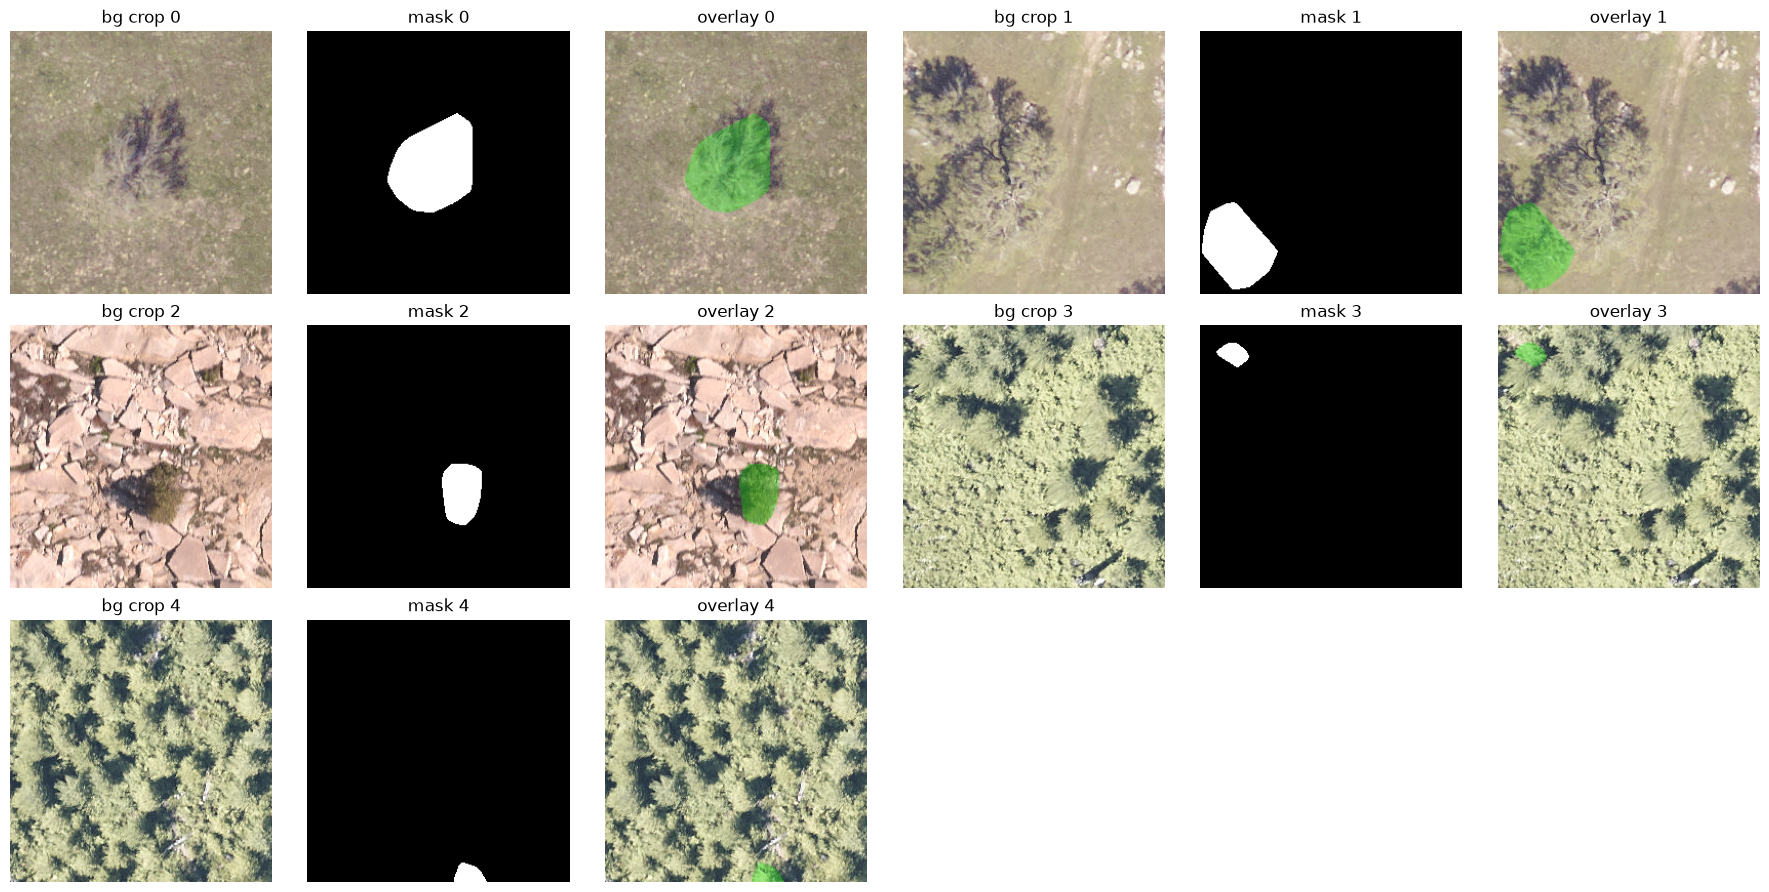

In [17]:
# Visualize background-expanded crops
if len(background_crops_ind) >= max_demo_samples:
    triplets = []
    titles = []

    for i in range(max_demo_samples):
        crop_img = background_crops_ind[i]
        crop_mask = background_masks_ind[i]

        # Create overlay
        overlay = crop_img.copy()
        overlay[crop_mask > 0] = [0, 255, 0]  # Green for trees
        overlay = cv2.addWeighted(crop_img, 0.7, overlay, 0.3, 0)

        triplets.extend([crop_img, crop_mask * 255, overlay])
        titles.extend([f"bg crop {i}", f"mask {i}", f"overlay {i}"])

    show_side_by_side(*triplets, titles = tuple(titles), maxcolumns = 6)


#### Step 4: Train model on only individual class

In [18]:
train_tf = get_train_augmentations(config.train.image_size)
val_tf = get_val_augmentations(config.train.image_size)

train_ds_ind = ImageMaskDataset(
        individual_entries,
        image_dir,
        classes = ["individual_tree"],
        transform = train_tf
)

val_ds_ind = ImageMaskDataset(
        individual_entries[:20],
        image_dir,
        classes = ["individual_tree"],
        transform = val_tf
)

train_loader_ind = DataLoader(train_ds_ind, batch_size = config.train.batch_size, shuffle = True)
val_loader_ind = DataLoader(val_ds_ind, batch_size = config.train.batch_size, shuffle = False)

# CREATE UNIQUE PATH for individual tree model
individual_model_path = config.paths.models / "07" / "individual_tree_only" / "simple_cnn" / "rgb"

trainer_ind = run_training(
        config,
        train_loader_ind,
        val_loader_ind,
        individual_model_path,  # Use unique path
        model_name = "simple_cnn"
)


=== Validating Training ===
Image Batch 0::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.364, 2.640]
Mask Batch 0::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 1::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.458, 2.623]
Mask Batch 1::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 2::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-2.118, 2.043]
Mask Batch 2::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
=== Validating Validation ===
Image Batch 0::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.160, 2.501]
Mask Batch 0::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 1::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.638, 2.623]
Mask Batch 1::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 2::   Images: t

#### Step 5: Train model on only group class

In [19]:
# Load individual tree model

individual_vm = VersionManager(individual_model_path)
individual_version_dir = individual_vm.find_latest()
individual_model_file = individual_version_dir / "best_model.pth"

predictor_ind = Predictor(
        individual_model_file,
        model_name = "simple_cnn",
        image_size = config.train.image_size
)

results_single = predictor_ind.run_on_folder(
        image_dir,
        transform = get_val_augmentations(config.train.image_size)
)

p("Individual tree predictions", len(results_single))


[Info]: Loaded model weights from /Volumes/Colibri/Projects/cap6415-tree-canopy-detection/checkpoints/07/individual_tree_only/simple_cnn/rgb/v001/best_model.pth
Processed 5/14 images
Processed 10/14 images
Individual tree predictions: 14


#### Step 6: Run single-class model on all images and save predictions

In [20]:
# Public NEON sample has no group_of_trees — skip this block when empty
group_model_path = config.paths.models / "07" / "group_trees_only" / "simple_cnn" / "rgb"
trainer_grp = None

if not group_entries:
    p(
        "Skip group-only training",
        "No group_of_trees in active dataset (expected for public NEON sample)",
        color1=c.ORANGE,
    )
else:
    train_ds_grp = ImageMaskDataset(
        group_entries,
        image_dir,
        classes=["group_of_trees"],
        transform=train_tf,
    )
    val_ds_grp = ImageMaskDataset(
        group_entries[:20],
        image_dir,
        classes=["group_of_trees"],
        transform=val_tf,
    )
    train_loader_grp = DataLoader(
        train_ds_grp, batch_size=config.train.batch_size, shuffle=True
    )
    val_loader_grp = DataLoader(
        val_ds_grp, batch_size=config.train.batch_size, shuffle=False
    )
    trainer_grp = run_training(
        config,
        train_loader_grp,
        val_loader_grp,
        group_model_path,
        model_name="simple_cnn",
    )


Skip group-only training: No group_of_trees in active dataset (expected for public NEON sample)


#### Step 7: Run group-class model on all images

In [21]:
# Load group tree model (skipped when public sample has no groups)
results_group = []
all_groups = []

if trainer_grp is None and not group_entries:
    p(
        "Skip group predictions",
        "No group_of_trees model — public sample is individual_tree only",
        color1=c.ORANGE,
    )
else:
    group_vm = VersionManager(group_model_path)
    group_version_dir = group_vm.find_latest()
    if group_version_dir is None:
        p("Skip group predictions", "No group checkpoint found", color1=c.ORANGE)
    else:
        group_model_file = group_version_dir / "best_model.pth"
        predictor_grp = Predictor(
            group_model_file,
            model_name="simple_cnn",
            image_size=config.train.image_size,
        )
        results_group = predictor_grp.run_on_folder(
            image_dir,
            transform=get_val_augmentations(config.train.image_size),
        )
        all_groups = results_group
        p("Group tree predictions", len(all_groups))


Skip group predictions: No group_of_trees model — public sample is individual_tree only


#### Step 8: Final combined training

In [22]:
import copy
import time

combined_entries = individual_entries + group_entries

train_ds_comb = ImageMaskDataset(combined_entries, image_dir, transform = train_tf)
val_ds_comb = ImageMaskDataset(combined_entries[:40], image_dir, transform = val_tf)

train_loader_final = DataLoader(train_ds_comb, batch_size = config.train.batch_size, shuffle = True)
val_loader_final = DataLoader(val_ds_comb, batch_size = config.train.batch_size, shuffle = False)

# CREATE UNIQUE PATH for combined model
combined_model_path = config.paths.models / "07" / "combined_classes" / "simple_cnn" / "rgb"

model_name, mode, in_channels = "simple_cnn", "rgb", "3"

exp_config = copy.deepcopy(config)
exp_config.extra['force_retrain'] = time.time()

trainer_final = run_training(
        exp_config,
        train_loader_final,
        val_loader_final,
        combined_model_path,  # Use unique path
        model_name = "simple_cnn"
)


=== Validating Training ===
Image Batch 0::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.947, 2.466]
Mask Batch 0::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 1::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.656, 2.518]
Mask Batch 1::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 2::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.570, 2.640]
Mask Batch 2::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
=== Validating Validation ===
Image Batch 0::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.160, 2.501]
Mask Batch 0::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 1::   Images: torch.Size([2, 3, 128, 128]), dtype=torch.float32, range=[-1.638, 2.623]
Mask Batch 1::   Masks: torch.Size([2, 128, 128]), dtype=torch.int64, unique=[0, 1]
Image Batch 2::   Images: t

In [23]:
if trainer_final is not None:
    t("Final Combined Trainer Metrics")

    # Load checkpoint to get metrics
    checkpoint_path = trainer_final.paths["checkpoint"]
    if checkpoint_path.exists():
        ckpt = torch.load(checkpoint_path, map_location = "cpu")

        p("")

        p("Model", "simple_cnn (combined)", color1 = c.GREEN)
        p("Best Val Loss", f"{ckpt.get('best_val_loss', 0):.6f}", color1 = c.GREEN)
        p("Final Epoch", ckpt.get('final_epoch', ckpt.get('epoch', 0)), color1 = c.GREEN)
        p("Train Loss", f"{ckpt.get('train_loss', 0):.6f}", color1 = c.GREEN)
        p("")

        p("Validation Metrics", color1 = c.CYAN, bold = True)
        p("Val Loss", f"{ckpt.get('val_loss', 0):.6f}", color1 = c.BLUE)
        p("Val IoU", f"{ckpt.get('val_iou', ckpt.get('iou', 0)):.4f}", color1 = c.BLUE)
        p("Val Accuracy", f"{ckpt.get('val_accuracy', ckpt.get('accuracy', 0)):.4f}", color1 = c.BLUE)
        p("Individual Tree IoU", f"{ckpt.get('val_iou_individual', 0):.4f}", color1 = c.BLUE)
        p("Group Tree IoU", f"{ckpt.get('val_iou_group', 0):.4f}", color1 = c.BLUE)
        p("")

        p("Version", trainer_final.version_dir.name, color1 = c.CYAN)
        p("Path", str(trainer_final.version_dir), color1 = c.BLUE)
        p("")

    else:
        p("ERROR", "No checkpoint found!", color1 = c.RED)
else:
    p("WARNING", "Trainer is None - training was skipped", color1 = c.ORANGE)


=== Final Combined Trainer Metrics ===

Model: simple_cnn (combined)
Best Val Loss: 0.824732
Final Epoch: 4
Train Loss: 0.911997

Validation Metrics
Val Loss: 0.824732
Val IoU: 0.2478
Val Accuracy: 0.7557
Individual Tree IoU: 0.4955
Group Tree IoU: 0.0000

Version: v001
Path: /Volumes/Colibri/Projects/cap6415-tree-canopy-detection/checkpoints/07/combined_classes/simple_cnn/rgb/v001



In [24]:
if trainer_final is not None:
    checkpoint_path = trainer_final.paths["checkpoint"]
    if checkpoint_path.exists():
        ckpt = torch.load(checkpoint_path, map_location = "cpu")

        analyze_validation_metrics(
                val_loss = ckpt.get("val_loss", 0),
                iou = ckpt.get("val_iou", ckpt.get("iou", 0)),
                accuracy = ckpt.get("val_accuracy", ckpt.get("accuracy", 0)),
                individual_tree_iou = ckpt.get("val_iou_individual", 0),
                group_tree_iou = ckpt.get("val_iou_group", 0),
                model_name = "Group Tree Model"
        )


=== Group Tree Model Performance Analysis ===
Performance Categories: 🥇 excellent |🥈 good |🥉 fair | 😡 poor

Overall Performance: FAIR
Overall Score: 1.60/4.0

=== Metric Breakdown: ===
  🥉 Val Loss: 0.8247 (fair)
  😡 Iou: 24.8% (poor)
  🥉 Accuracy: 75.6% (fair)
  🥉 Individual Tree Iou: 49.6% (fair)
  😡 Group Tree Iou: 0.0% (poor)

=== Concerns: ===
  • Low iou (24.8%) indicates poor iou
  • Low group_tree_iou (0.0%) indicates poor group tree iou

=== Recommendations: ===
  • Fine-tune hyperparameters
  • Try different augmentations
  • Consider ensemble methods
